In [5]:
import csv
import re
import unicodedata
from pathlib import Path

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import os

In [6]:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

image_size = 128
latent_dim = 128
batch_size = 64
epochs = 50

lr = 0.0002
beta1 = 0.0
beta2 = 0.99

Using device: mps


In [7]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5, 0.5], [0.5, 0.5, 0.5, 0.5])
])

def normalize_name(name):
    name = name.strip().lower().replace("_", " ")
    name = unicodedata.normalize("NFKD", name)
    name = "".join(ch for ch in name if not unicodedata.combining(ch))
    name = re.sub(r"[^a-z0-9\s]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

class PokemonTypeDataset(Dataset):
    def __init__(self, image_root, csv_path, transform=None):
        self.image_root = Path(image_root)
        self.csv_path = Path(csv_path)
        self.transform = transform

        if not self.image_root.exists():
            raise FileNotFoundError(f"Image root not found: {self.image_root}")
        if not self.csv_path.exists():
            raise FileNotFoundError(f"CSV not found: {self.csv_path}")

        name_to_type = {}
        with open(self.csv_path, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                pokemon_name = row["Pokemon"].strip()
                primary_type = row["Type"].split(",")[0].strip()
                name_to_type[normalize_name(pokemon_name)] = primary_type

        all_png = sorted([p for p in self.image_root.rglob("*.png") if p.is_file()])
        records = []
        unmatched = []

        for path in all_png:
            stem = path.stem
            if stem.lower().endswith("_new"):
                stem = stem[:-4]
            key = normalize_name(stem)

            primary_type = name_to_type.get(key)
            if primary_type is None:
                unmatched.append(path.name)
                continue

            records.append((path, primary_type))

        if not records:
            raise RuntimeError("No images matched with CSV Pokemon names.")

        self.type_names = sorted({t for _, t in records})
        self.type_to_idx = {t: i for i, t in enumerate(self.type_names)}
        self.samples = [(p, self.type_to_idx[t]) for p, t in records]
        self.unmatched = unmatched

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, type_idx = self.samples[idx]
        image = Image.open(path).convert("RGBA")
        if self.transform is not None:
            image = self.transform(image)
        return image, type_idx

dataset_roots = {
    128: "../testMohamed/archive32/PokemonImagesDBNew_square/square_128",
    256: "../testMohamed/archive32/PokemonImagesDBNew_square/square_256",
}

if image_size not in dataset_roots:
    raise ValueError(f"Unsupported image_size={image_size}. Use one of: {list(dataset_roots.keys())}")

dataset = PokemonTypeDataset(
    image_root=dataset_roots[image_size],
    csv_path="./pokemonDB_dataset.csv",
    transform=transform,
)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

num_types = len(dataset.type_names)
print(f"Matched images: {len(dataset)}")
print(f"Types: {num_types}")
if dataset.unmatched:
    print(f"Unmatched files: {len(dataset.unmatched)} (examples: {dataset.unmatched[:5]})")

Matched images: 1169
Types: 18
Unmatched files: 18 (examples: ['Arbolive_new.png', 'Eevee (Partner Eevee)_new.png', 'Greninja (Ash-Greninja)_new.png', 'Hoopa (Hoopa Confined)_new.png', 'Hoopa (Hoopa Unbound)_new.png'])


In [8]:
class MappingNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        type_embed_dim = 32
        self.type_embed = nn.Embedding(num_types, type_embed_dim)

        self.net = nn.Sequential(
            nn.Linear(latent_dim + type_embed_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256)
)

    def forward(self, z, type_idx):
        type_vec = self.type_embed(type_idx)
        x = torch.cat([z, type_vec], dim=1)
        return self.net(x)

In [9]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        if image_size < 16 or (image_size & (image_size - 1)) != 0:
            raise ValueError("image_size must be a power of 2 and >= 16")

        layers = [
            nn.ConvTranspose2d(256, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        ]

        current_size = 4
        in_ch = 512
        next_ch = 256

        while current_size < image_size:
            out_ch = max(32, next_ch)
            layers.extend([
                nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1),
                nn.BatchNorm2d(out_ch),
                nn.LeakyReLU(0.2),
            ])
            in_ch = out_ch
            next_ch //= 2
            current_size *= 2

        layers.extend([
            nn.Conv2d(in_ch, 4, 3, 1, 1),
            nn.Tanh(),
        ])

        self.net = nn.Sequential(*layers)

    def forward(self, w):
        w = w.view(-1, 256, 1, 1)
        return self.net(w)

In [10]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        if image_size < 16 or (image_size & (image_size - 1)) != 0:
            raise ValueError("image_size must be a power of 2 and >= 16")

        self.cond_channels = 16
        self.type_embed = nn.Embedding(num_types, self.cond_channels)

        layers = []
        current_size = image_size
        in_ch = 4 + self.cond_channels
        out_ch = 64
        first_block = True

        while current_size > 4:
            layers.append(nn.Conv2d(in_ch, out_ch, 4, 2, 1))
            if not first_block:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.LeakyReLU(0.2))

            in_ch = out_ch
            out_ch = min(out_ch * 2, 512)
            current_size //= 2
            first_block = False

        layers.extend([
            nn.Conv2d(in_ch, 1, 4, 1, 0),
            nn.Sigmoid(),
        ])

        self.net = nn.Sequential(*layers)

    def forward(self, x, type_idx):
        cond = self.type_embed(type_idx).unsqueeze(-1).unsqueeze(-1)
        cond = cond.expand(-1, -1, x.size(2), x.size(3))
        x = torch.cat([x, cond], dim=1)
        return self.net(x).view(-1)

In [11]:
G = Generator().to(device)
D = Discriminator().to(device)
M = MappingNetwork().to(device)

criterion = nn.BCELoss()

opt_G = torch.optim.Adam(
    list(G.parameters()) + list(M.parameters()),
    lr=lr,
    betas=(beta1,beta2)
)

opt_D = torch.optim.Adam(
    D.parameters(),
    lr=lr,
    betas=(beta1,beta2)
)

In [12]:
for epoch in range(epochs):

    for real, type_idx in tqdm(loader):

        real = real.to(device)
        type_idx = type_idx.to(device)
        b = real.size(0)

        real_label = torch.ones(b).to(device)
        fake_label = torch.zeros(b).to(device)

        # Train Discriminator

        opt_D.zero_grad()

        out_real = D(real, type_idx)
        loss_real = criterion(out_real, real_label)

        z = torch.randn(b, latent_dim).to(device)
        w = M(z, type_idx)

        fake = G(w)

        out_fake = D(fake.detach(), type_idx)
        loss_fake = criterion(out_fake, fake_label)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # Train Generator

        opt_G.zero_grad()

        out = D(fake, type_idx)

        loss_G = criterion(out, real_label)
        loss_G.backward()

        opt_G.step()

    print(epoch, loss_D.item(), loss_G.item())

 58%|█████▊    | 11/19 [00:22<00:16,  2.06s/it]


KeyboardInterrupt: 

(np.float64(-0.5), np.float64(1041.5), np.float64(1041.5), np.float64(-0.5))

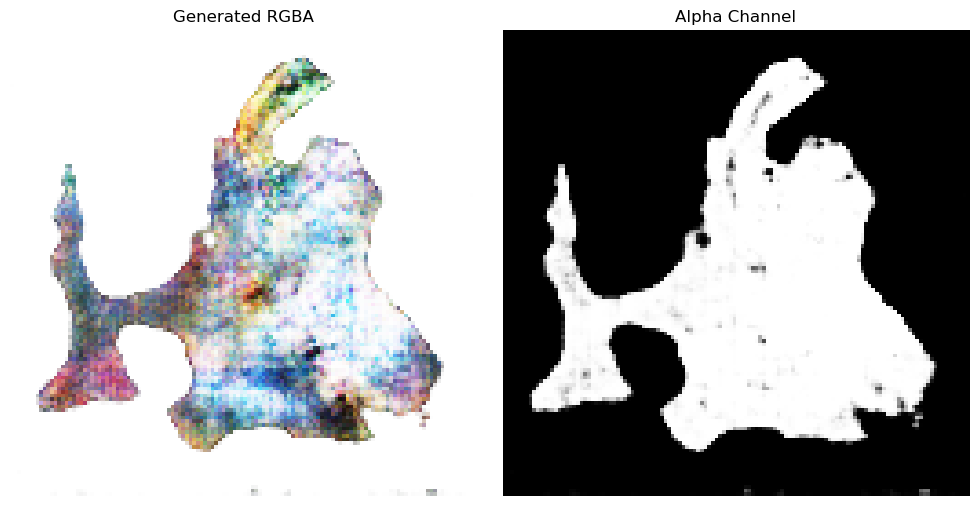

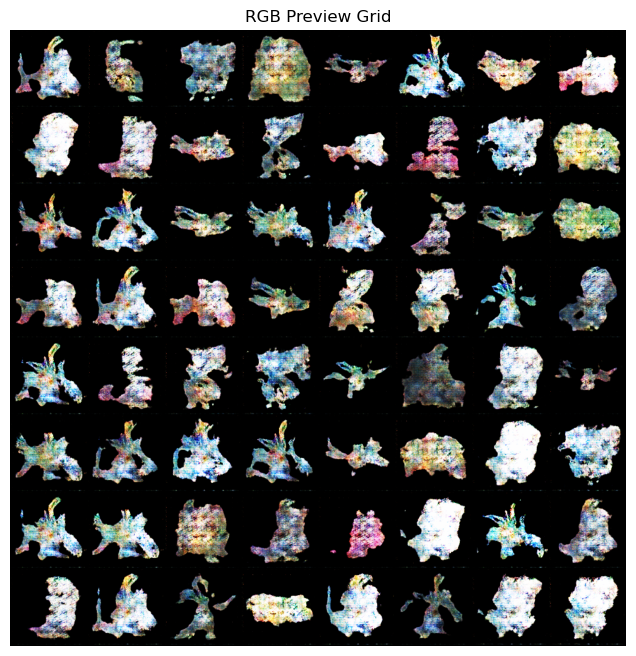

In [ ]:
z = torch.randn(64, latent_dim).to(device)
sample_types = torch.randint(0, num_types, (64,), device=device)
w = M(z, sample_types)
fake = G(w).detach().cpu()

# Convert from [-1, 1] to [0, 1] for visualization.
fake_vis = (fake + 1) / 2
fake_vis = fake_vis.clamp(0, 1)

# Show one sample as RGBA + its alpha mask.
sample_rgba = fake_vis[0].permute(1, 2, 0).numpy()
sample_alpha = fake_vis[0, 3].numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_rgba)
axes[0].set_title("Generated RGBA")
axes[0].axis("off")

axes[1].imshow(sample_alpha, cmap="gray")
axes[1].set_title("Alpha Channel")
axes[1].axis("off")
plt.tight_layout()

# Optional: RGB grid preview for quick batch inspection.
rgb_grid = torchvision.utils.make_grid(fake_vis[:, :3], nrow=8)
plt.figure(figsize=(8, 8))
plt.imshow(rgb_grid.permute(1, 2, 0))
plt.title("RGB Preview Grid")
plt.axis("off")

print("Sample types (first 8):", [dataset.type_names[i] for i in sample_types[:8].cpu().tolist()])